# 01 · Neural Network Fundamentals — Code

We build a small feedforward network **twice**:
1. **Part A — NumPy from scratch:** perceptron, activations, losses, forward prop, and manual backpropagation using the chain rule — nothing hidden.
2. **Part B — PyTorch equivalent:** the same network using `nn.Module` and `autograd`, so you can see exactly what's being automated.

Task: binary classification on a toy 2D dataset (two interleaving moons) so we can also visualize the decision boundary.

# Part A — NumPy From Scratch

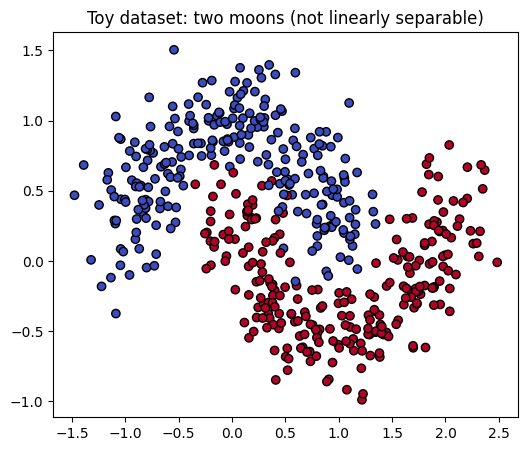

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Toy dataset: two interleaving half-moons (not linearly separable)
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.title("Toy dataset: two moons (not linearly separable)")
plt.show()

## 1. The Perceptron

In [2]:
def perceptron_forward(x, w, b):
    """A single perceptron: weighted sum + bias, then a step activation."""
    z = np.dot(x, w) + b
    return 1 if z > 0 else 0

# Demo: a single perceptron CANNOT solve XOR (classic limitation)
XOR_X = np.array([[0,0], [0,1], [1,0], [1,1]])
XOR_y = np.array([0, 1, 1, 0])

w = np.array([0.5, 0.5])
b = -0.5
preds = [perceptron_forward(x, w, b) for x in XOR_X]
print("XOR inputs:\n", XOR_X)
print("XOR targets:  ", XOR_y)
print("Perceptron predictions (no fixed w,b will ever match all 4):", preds)
print("\nThis is exactly why we need MULTIPLE layers of perceptrons (a network).")

XOR inputs:
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]
XOR targets:   [0 1 1 0]
Perceptron predictions (no fixed w,b will ever match all 4): [0, 0, 0, 1]

This is exactly why we need MULTIPLE layers of perceptrons (a network).


## 2-3. Activation Functions & Forward Propagation

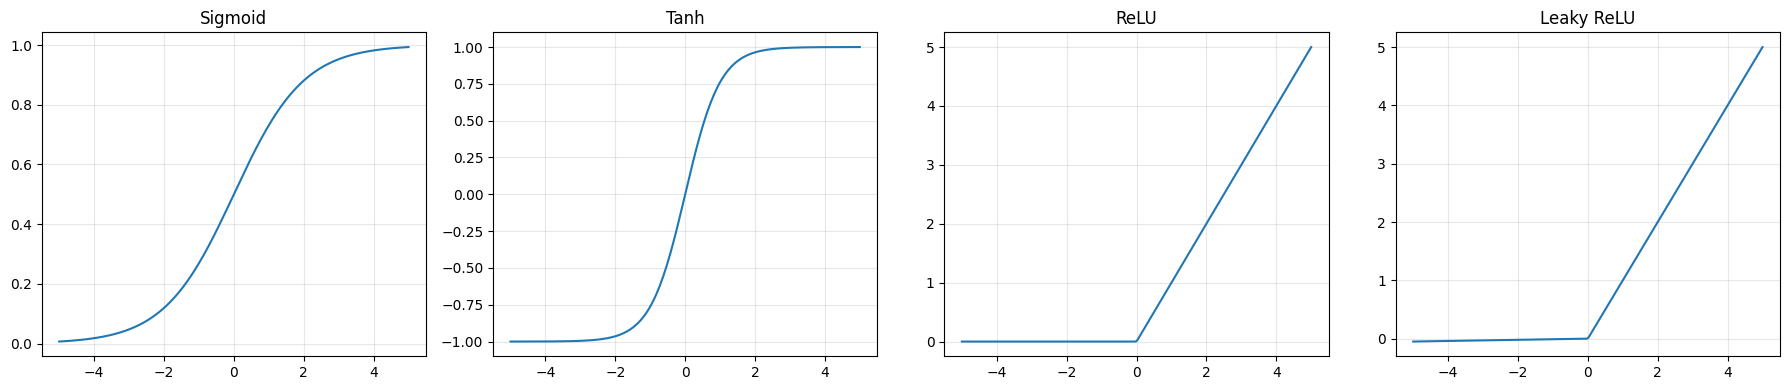

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_derivative(a):
    # a = sigmoid(z) already computed
    return a * (1 - a)

def tanh(z):
    return np.tanh(z)

def tanh_derivative(a):
    return 1 - a**2

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def leaky_relu_derivative(z, alpha=0.01):
    return np.where(z > 0, 1.0, alpha)

def softmax(z):
    z_shift = z - np.max(z, axis=1, keepdims=True)  # numerical stability
    exp_z = np.exp(z_shift)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Visualize all activations
z = np.linspace(-5, 5, 200)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].plot(z, sigmoid(z)); axes[0].set_title('Sigmoid'); axes[0].grid(alpha=0.3)
axes[1].plot(z, tanh(z)); axes[1].set_title('Tanh'); axes[1].grid(alpha=0.3)
axes[2].plot(z, relu(z)); axes[2].set_title('ReLU'); axes[2].grid(alpha=0.3)
axes[3].plot(z, leaky_relu(z)); axes[3].set_title('Leaky ReLU'); axes[3].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Loss Functions

In [4]:
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def binary_cross_entropy(y_true, y_pred, eps=1e-9):
    y_pred = np.clip(y_pred, eps, 1 - eps)  # avoid log(0)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def categorical_cross_entropy(y_true_onehot, y_pred, eps=1e-9):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(np.sum(y_true_onehot * np.log(y_pred), axis=1))

# Quick sanity check: BCE penalizes confident wrong predictions much more than MSE does
y_true = np.array([1.0])
for y_pred in [0.9, 0.5, 0.1, 0.01]:
    print(f"y_pred={y_pred:.2f} -> MSE={mse_loss(y_true, np.array([y_pred])):.4f}  "
          f"BCE={binary_cross_entropy(y_true, np.array([y_pred])):.4f}")

y_pred=0.90 -> MSE=0.0100  BCE=0.1054
y_pred=0.50 -> MSE=0.2500  BCE=0.6931
y_pred=0.10 -> MSE=0.8100  BCE=2.3026
y_pred=0.01 -> MSE=0.9801  BCE=4.6052


## 5-7. Building the Network: Forward Prop, Backprop (Chain Rule), Gradient Descent

A 2-layer network: `Input(2) -> Hidden(8, ReLU) -> Output(1, Sigmoid)`, trained with Binary Cross-Entropy and manual backpropagation.

In [5]:
class SimpleNeuralNetwork:
    def __init__(self, input_dim, hidden_dim, output_dim, lr=0.1):
        # Random initialization (see lesson 05 for *why* this matters)
        self.W1 = np.random.randn(input_dim, hidden_dim) * 0.1
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * 0.1
        self.b2 = np.zeros((1, output_dim))
        self.lr = lr

    def forward(self, X):
        # ---- Forward propagation ----
        self.z1 = X @ self.W1 + self.b1
        self.a1 = relu(self.z1)                 # hidden activation
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = sigmoid(self.z2)               # output activation (prediction)
        return self.a2

    def backward(self, X, y):
        n = X.shape[0]

        # ---- Backpropagation via the chain rule ----
        # dL/da2 = derivative of BCE w.r.t. sigmoid output; combined with sigmoid'
        #          simplifies beautifully to (a2 - y) -- this IS the chain rule at work
        dz2 = (self.a2 - y) / n                       # dL/dz2  (chain rule collapses here)
        dW2 = self.a1.T @ dz2                          # dL/dW2 = dL/dz2 * dz2/dW2
        db2 = np.sum(dz2, axis=0, keepdims=True)

        da1 = dz2 @ self.W2.T                           # dL/da1 = dL/dz2 * dz2/da1
        dz1 = da1 * relu_derivative(self.z1)             # dL/dz1 = dL/da1 * da1/dz1 (chain rule)
        dW1 = X.T @ dz1                                   # dL/dW1 = dL/dz1 * dz1/dW1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # ---- Gradient descent update ----
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def train(self, X, y, epochs=2000, verbose=True):
        losses = []
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = binary_cross_entropy(y, y_pred)
            losses.append(loss)
            self.backward(X, y)
            if verbose and epoch % 400 == 0:
                acc = np.mean((y_pred > 0.5) == y)
                print(f"Epoch {epoch:4d}  Loss: {loss:.4f}  Accuracy: {acc:.3f}")
        return losses

net = SimpleNeuralNetwork(input_dim=2, hidden_dim=8, output_dim=1, lr=0.5)
losses = net.train(X_train, y_train, epochs=2000)

Epoch    0  Loss: 0.7036  Accuracy: 0.237
Epoch  400  Loss: 0.2795  Accuracy: 0.858
Epoch  800  Loss: 0.2792  Accuracy: 0.858


Epoch 1200  Loss: 0.2792  Accuracy: 0.858
Epoch 1600  Loss: 0.2792  Accuracy: 0.858


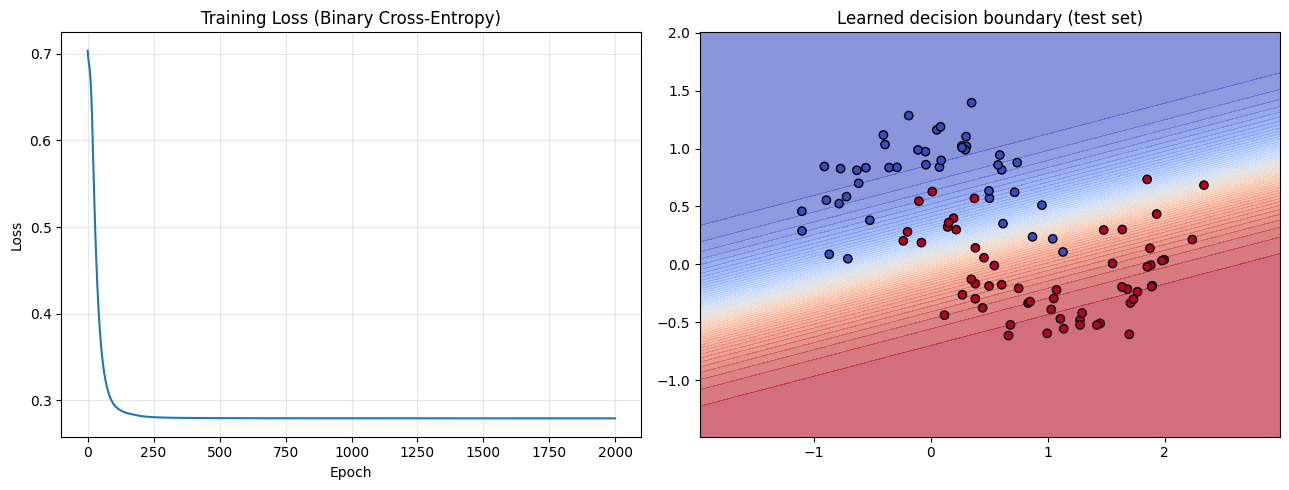

NumPy-from-scratch network test accuracy: 0.860


In [6]:
# Plot training loss and the learned decision boundary
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(losses)
axes[0].set_title("Training Loss (Binary Cross-Entropy)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].grid(alpha=0.3)

xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 200),
                      np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
preds = net.forward(grid).reshape(xx.shape)

axes[1].contourf(xx, yy, preds, levels=50, cmap='coolwarm', alpha=0.6)
axes[1].scatter(X_test[:,0], X_test[:,1], c=y_test.ravel(), cmap='coolwarm', edgecolors='k')
axes[1].set_title("Learned decision boundary (test set)")

plt.tight_layout()
plt.show()

test_pred = net.forward(X_test)
test_acc = np.mean((test_pred > 0.5) == y_test)
print(f"NumPy-from-scratch network test accuracy: {test_acc:.3f}")

---
# Part B — PyTorch Equivalent

Same architecture, same dataset. `autograd` computes every gradient we derived by hand above automatically.

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

class TorchNet(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=8, output_dim=1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))     # forward propagation, layer 1
        x = self.sigmoid(self.fc2(x))  # forward propagation, layer 2 (output)
        return x

model = TorchNet()
criterion = nn.BCELoss()                       # same Binary Cross-Entropy as Part A
optimizer = optim.SGD(model.parameters(), lr=0.5)  # same plain gradient descent as Part A

torch_losses = []
for epoch in range(2000):
    optimizer.zero_grad()               # clear old gradients
    y_pred = model(X_train_t)           # forward pass
    loss = criterion(y_pred, y_train_t)
    loss.backward()                     # <-- autograd does ALL of Part A's manual backprop here
    optimizer.step()                    # <-- gradient descent weight update
    torch_losses.append(loss.item())
    if epoch % 400 == 0:
        acc = ((y_pred > 0.5) == y_train_t).float().mean().item()
        print(f"Epoch {epoch:4d}  Loss: {loss.item():.4f}  Accuracy: {acc:.3f}")

Epoch    0  Loss: 0.7123  Accuracy: 0.490


Epoch  400  Loss: 0.1716  Accuracy: 0.928


Epoch  800  Loss: 0.0875  Accuracy: 0.978


Epoch 1200  Loss: 0.0714  Accuracy: 0.978


Epoch 1600  Loss: 0.0659  Accuracy: 0.978


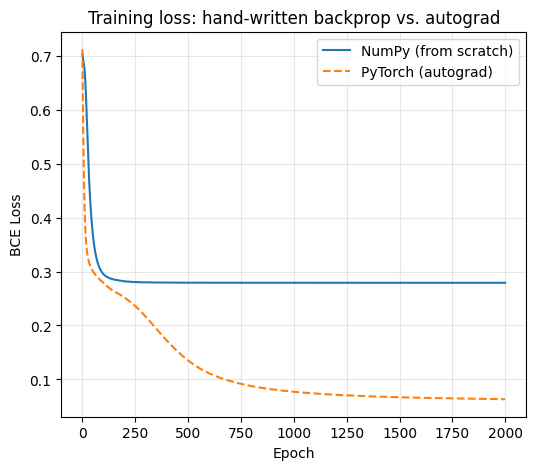

NumPy  test accuracy: 0.860
PyTorch test accuracy: 0.990

Both implement the exact same math -- PyTorch just computed the chain rule for you.


In [8]:
with torch.no_grad():
    test_pred_t = model(X_test_t)
    test_acc_t = ((test_pred_t > 0.5) == y_test_t).float().mean().item()

plt.figure(figsize=(6,5))
plt.plot(losses, label='NumPy (from scratch)')
plt.plot(torch_losses, label='PyTorch (autograd)', linestyle='--')
plt.title("Training loss: hand-written backprop vs. autograd")
plt.xlabel("Epoch"); plt.ylabel("BCE Loss"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

print(f"NumPy  test accuracy: {test_acc:.3f}")
print(f"PyTorch test accuracy: {test_acc_t:.3f}")
print("\nBoth implement the exact same math -- PyTorch just computed the chain rule for you.")